# Practical — Training Object Detectors on Aerial Wildlife Data

**Context:** In the previous practicals you used pre-trained models (MegaDetector, SpeciesNet). In the domain shift notebook you saw that MegaDetector
fails on aerial imagery. The solution? **Train your own detector.**

This notebook walks through two training approaches on the **Eikelboom** aerial
wildlife dataset (elephants, zebras, giraffes from Kenyan drone surveys):

| Approach | Model | Annotation type | Output |
|----------|-------|----------------|--------|
| **Part A** | YOLOv8 | Bounding boxes | Boxes + class labels |
| **Part B** | HerdNet (simplified) | Point annotations | Density heatmap + counts |

Both use the same tiled images (640x640 px), but different annotation formats:
- YOLO uses `class cx cy w h` (normalized bounding boxes)
- HerdNet uses `(x, y)` point annotations → FIDT density maps

**Goal:** Understand the training loop, not achieve state-of-the-art. We train
for just a few epochs to see the pipeline work end-to-end.

---

## Environment Setup

**Local (recommended):** use the `fit-training` conda environment:

```bash
conda env create -f environment-training.yml
conda activate fit-training
```

**Google Colab:** uncomment and run the cell below.

In [1]:
# Colab only — install dependencies if not already available
# import sys

# !git clone  https://github.com/cwinkelmann/usde-innovations-applications-forest-it.git fit-course
# !cd fit-course && git pull
# !pip install -e "./fit-course[training,dev]"
#
# # sys.path is handled by pip install -e above — no manual append needed

### Notes on Real life complexity
There is no single way to train a model — newer and better model are seldomly plug-and-play nor are they guaranteeing to improve end user results just because an F1 Score went up.

A great in practice YouTube Channel is [DigitalSreeni](https://www.youtube.com/watch?v=LvqzKr-dORQ) which explains the practicalities of training and deploying all kinds of machine Learning models like CNN classifiers to Cell Segmentation and Object Detection models. He also has a great playlist on YOLO training which is very practical and hands-on.

For a little overview how YOLO training works in practice look here:
[YOLO training](https://www.youtube.com/watch?v=A1V8yYlGEkI&list=PLUE9cBml08ygpA4AM1JXHLcO-d_87pGIt&index=2)

In [2]:
%matplotlib inline

from pathlib import Path
import json

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

DATA_DIR      = Path.cwd().parent / "data"
YOLO_RUNS_DIR = DATA_DIR / "yolo_runs"      # absolute — avoids Ultralytics path quirks

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device   : {DEVICE}")
print(f"Data dir : {DATA_DIR.resolve()}")


Device   : mps
Data dir : /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data


In [3]:
# ── What to train on ─────────────────────────────────────────────────────
# Point DATA_YAML at any YOLO dataset.yaml.
# Default: the human-reviewed camera trap annotations exported from Practical 7.
DATA_YAML = str(DATA_DIR / "label_studio_yolo" / "data.yaml")
assert Path(DATA_YAML).exists(), (
    f"YOLO dataset not found: {DATA_YAML}\n"
    "Run Practical 7 first and complete the export cell."
)

# ── Pretrained weights to fine-tune from ──────────────────────────────────
# MegaDetector v1000 'spruce' (YOLOv5s, 13 MB, MIT licence) — edge-optimised.
# Swap to md_v1000.0.0-larch.pt (YOLO11L, 25 MB) for higher accuracy.
WEIGHTS = Path.cwd().parent.parent / "weights" / "md_v1000.0.0-larch.pt"

if not WEIGHTS.exists():
    import urllib.request, sys
    url = "https://github.com/agentmorris/MegaDetector/releases/download/v1000.0/md_v1000.0.0-larch.pt"
    print("Downloading spruce weights (~13 MB) ...")
    WEIGHTS.parent.mkdir(parents=True, exist_ok=True)
    def _progress(count, block, total):
        pct = min(count * block * 100 // total, 100)
        sys.stdout.write(f"\r  {pct}%"); sys.stdout.flush()
    urllib.request.urlretrieve(url, WEIGHTS, reporthook=_progress)
    print(f"\n  Saved to {WEIGHTS}")

WEIGHTS = str(WEIGHTS)
print(f"Dataset : {DATA_YAML}")
print(f"Weights : {WEIGHTS}")


Dataset : /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/label_studio_yolo/data.yaml
Weights : /Users/christian/work/hnee/usde-innovations-applications-forest-it/weights/md_v1000.0.0-larch.pt


---

## 1 — Fine-tune YOLOv8 on your annotated data

We start from **MegaDetector v1000 'larch'** (YOLO11L, pre-trained on millions
of camera trap images) and fine-tune it on the bounding boxes you reviewed and
corrected in Practical 7.

Fine-tuning from MegaDetector is faster and more accurate than training from
COCO weights — the backbone already understands animals in the field.


In [4]:
from ultralytics import YOLO

YOLO_EPOCHS = 10  # Increase to 50-100 for real training

model = YOLO(WEIGHTS)

results = model.train(
    data=DATA_YAML,
    epochs=YOLO_EPOCHS,
    imgsz=640,
    batch=8,
    device=DEVICE,
    freeze=10,     # freeze first 10 backbone layers — speeds up training on small datasets
    project=str(YOLO_RUNS_DIR),
    name="camera_trap_finetune",
    exist_ok=True,
    verbose=True,
)


New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.27 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/label_studio_yolo/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/Users/christian/work/h

## 2 — Evaluate on validation data


In [5]:
val_results = model.val(
    data=DATA_YAML,
    device=DEVICE,
)

print(f"\nValidation metrics after {YOLO_EPOCHS} epochs:")
print(f"  mAP@50      : {val_results.box.map50:.3f}")
print(f"  mAP@50-95   : {val_results.box.map:.3f}")
print(f"  Precision   : {val_results.box.mp:.3f}")
print(f"  Recall      : {val_results.box.mr:.3f}")


Ultralytics 8.4.27 🚀 Python-3.11.15 torch-2.11.0 MPS (Apple M2)
YOLO11l summary (fused): 191 layers, 25,295,503 parameters, 0 gradients, 86.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5374.9±88.7 MB/s, size: 205.9 KB)
val: Scanning /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/data/label_studio_yolo/labels.cache... 3 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3/3 3.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.5it/s 0.2s
                   all          3          4          0          0          0          0
             grey wolf          2          4          0          0          0          0
Speed: 0.4ms preprocess, 42.2ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /Users/christian/work/hnee/usde-innovations-applications-forest-it/week1/practicals/runs/detect/val4

Validation metrics after 10 epochs:
  mAP@50      : 0.000
  mAP@

## 3 — Visualize predictions


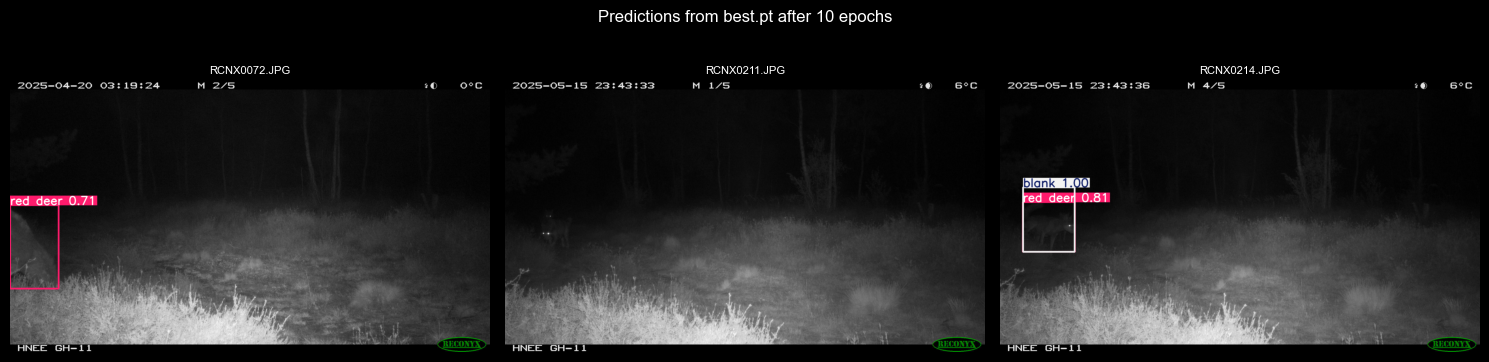

In [6]:
import yaml

# Reload best.pt — the model object after .train() retains training-graph
# state that breaks .predict(). Always load from the saved checkpoint.
best_pt = YOLO_RUNS_DIR / "camera_trap_finetune" / "weights" / "best.pt"
assert best_pt.exists(), f"best.pt not found: {best_pt}\nRun the training cell first."
inference_model = YOLO(str(best_pt))

# Load class names and image root from data.yaml
with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

img_root = Path(data_cfg["path"]) / data_cfg.get("val", "images")
sample_imgs = sorted(img_root.glob("*.jpg"))[:6] + sorted(img_root.glob("*.JPG"))[:6]
sample_imgs = [str(p) for p in sample_imgs[:6]]

if not sample_imgs:
    print("No images found — check DATA_YAML path.")
else:
    preds = inference_model.predict(sample_imgs, conf=0.25, verbose=False)

    ncols = min(3, len(sample_imgs))
    nrows = (len(sample_imgs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    for ax, pred, img_path in zip(np.array(axes).flat, preds, sample_imgs):
        ax.imshow(pred.plot()[:, :, ::-1])
        ax.set_title(Path(img_path).name, fontsize=8)
        ax.axis("off")
    plt.suptitle(f"Predictions from best.pt after {YOLO_EPOCHS} epochs", fontsize=12)
    plt.tight_layout()


## 4 — Training curves

Ultralytics saves metrics to a CSV after each epoch.


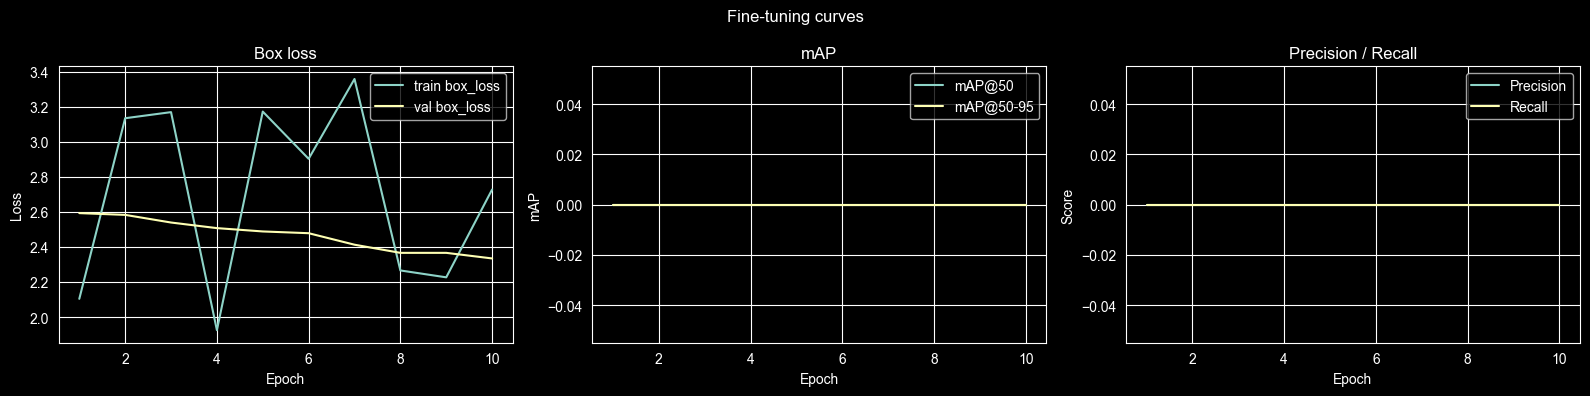

In [7]:
results_csv = YOLO_RUNS_DIR / "camera_trap_finetune" / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.plot(df["epoch"], df["train/box_loss"], label="train box_loss")
    ax.plot(df["epoch"], df["val/box_loss"],   label="val box_loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Box loss"); ax.legend()

    ax = axes[1]
    ax.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@50")
    ax.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95")
    ax.set_xlabel("Epoch"); ax.set_ylabel("mAP")
    ax.set_title("mAP"); ax.legend()

    ax = axes[2]
    ax.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
    ax.plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Score")
    ax.set_title("Precision / Recall"); ax.legend()

    plt.suptitle("Fine-tuning curves", fontsize=12)
    plt.tight_layout()
else:
    print(f"Results CSV not found: {results_csv}\nRun the training cell first.")


---

## Exercises

1. **More epochs** — Increase `YOLO_EPOCHS` to 50. How much does mAP improve?
   At what point do the training curves flatten?

2. **More data** — Go back to Practical 7, annotate more images, re-export and
   re-run training. How much does additional annotation improve results?

3. **Confidence threshold** — Change `conf=0.25` in the prediction cell.
   What happens to precision and recall as you raise or lower it?

4. Look up some datasets which you might be interested in training, which do not work that well with megadetector. Forinstance Puffins: [Puffins](https://universe.roboflow.com/seabirdai-hv30y/seabirds)


## Reflection

- You fine-tuned from MegaDetector weights rather than COCO. Why does this
  give better results for camera trap images? What does the backbone already know?

- The training set came from just a few dozen images reviewed in Practical 7.
  How many annotated images do you think you would need for a deployable model?

- False positives (background predicted as animal) and false negatives (missed
  animals) have different costs in wildlife monitoring. Which error would you
  optimise against, and how would you adjust the confidence threshold?
